In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA

import numpy as np
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pickle
import torch
import torchio as tio
import scipy.stats
import csv
import pandas as pd


## Analysis

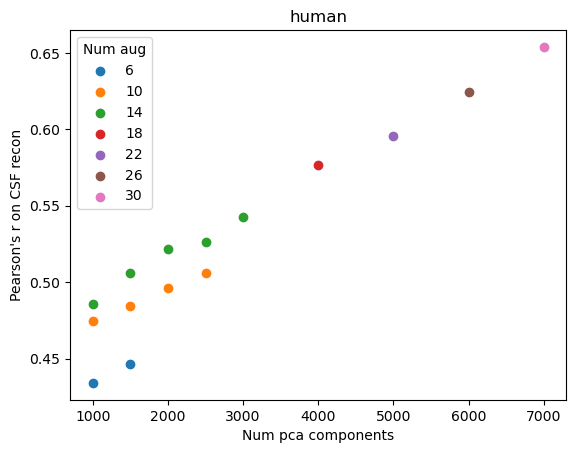

In [16]:
plt.figure()
labels = []
data_type = "human"
elastic_transf_type = "a"

pearsons_rs = pd.read_csv("./save_models_arc/save_pearsons_r.csv")


for i in [6,10,14, 18, 22, 26, 30]:
    df_filt = pearsons_rs[(pearsons_rs['num_aug'] == i) & (pearsons_rs['data_type'] == data_type) & (pearsons_rs['elastic_transf_type'] == elastic_transf_type)].sort_values(by='num_comp')

    pearsons_r = df_filt['gm_r']
    num_comp   = df_filt['num_comp']
    #plt.plot(num_comp, pearsons_r)
    plt.scatter(num_comp, pearsons_r)
    
    labels.append(str(i))

plt.xlabel("Num pca components")
plt.ylabel("Pearson's r on CSF recon")
leg = plt.legend(labels, title="Num aug")

plt.title(data_type)
plt.show()

In [ ]:
# Q - why is human data that different??? should they be the same sized matrix :/ ???


In [21]:
print(np.arange(2000, 4620, 500))

[2000 2500 3000 3500 4000 4500]


## Used for testing before putting in a script

In [2]:
# 1. load non augmented data
data_type = "human"

#####

def load_imgs(folder_path):
    images = []
    file_names = []

    for file_name in os.listdir(folder_path):
        img = sitk.ReadImage(folder_path + file_name)
        img_array = sitk.GetArrayFromImage(img).astype(np.float32)  # Normalize to [0, 1]
        images.append(img_array)

        file_names.append(file_name)

    # Convert to NumPy array: shape (n_images, height, width)
    images = np.stack(images).astype(np.float32)
    
    return images, file_names



In [9]:
folder_path = "../../../3D-CycleGan-Pytorch-MedImaging/data/"

if data_type == "mouse":
    train_imgs, _ = load_imgs(folder_path + "train/images/") # mouse
    test_imgs, _ = load_imgs(folder_path + "test/images/")
else:
    train_imgs, _ = load_imgs(folder_path + "train/labels/") # human
    test_imgs, _ = load_imgs(folder_path + "test/labels/")

In [3]:
# ANAT data
folder_path = "../../datasets/anat/"

if data_type == "mouse":
    train_imgs, _ = load_imgs(folder_path + "mouse_train/") # mouse
    test_imgs, _ = load_imgs(folder_path + "mouse_test/")
else:
    train_imgs, _ = load_imgs(folder_path + "human_train/") # human
    test_imgs, _ = load_imgs(folder_path + "human_test/")

In [4]:
print(data_type + ":")
print(train_imgs.shape)
print(train_imgs.dtype)

human:
(196, 128, 120, 120)
float32


In [5]:
aug_list = [train_imgs]

In [6]:
# 2. Augment the data

elastic_transf_type = "a"
num_aug = 6

#####
#train_imgs_aug = train_imgs

# Define transform
if elastic_transf_type == "a":
    num_control_points = 7
    max_displacement = 4.0
    locked_borders = 2

else:
    num_control_points = 5
    max_displacement = 2.0
    locked_borders = 5

elastic_transform = tio.RandomElasticDeformation(
    num_control_points=num_control_points,  # grid resolution, higher = more local warping
    max_displacement=max_displacement,  # max displacement in mm or voxels
    locked_borders=locked_borders,      # keep border fixed (avoid artifacts)
    image_interpolation='nearest'  # preserve label integrity
)

this_step_aug = []
for img in train_imgs:
    tensor = torch.from_numpy(img).unsqueeze(0).float()
    subject = tio.Subject(mask=tio.LabelMap(tensor=tensor))

    for i in range(num_aug):
        non_lin_transformed = elastic_transform(subject)
        non_lin_transformed = non_lin_transformed['mask'].data.squeeze(0).numpy()
        this_step_aug.append(non_lin_transformed[None, ...])  # keep dims

print("transf complete, now concat")
# Combine new aug with old ones
aug_list.append(np.concatenate(this_step_aug, axis=0))
train_imgs_aug = np.concatenate(aug_list, axis=0)

# takes ~1min 30s to concat to 6 augs or 3 min to 8 augs

transf complete, now concat


In [7]:
print(train_imgs_aug.shape)

(1372, 128, 120, 120)


In [8]:
# Shuffle and flatten train data (MEM EFFIC)
np.random.shuffle(train_imgs_aug)

train_imgs_aug = np.ascontiguousarray(train_imgs_aug)  # optional, ensures C-order
train_imgs_flat = train_imgs_aug.reshape(train_imgs_aug.shape[0], -1)

# mem efficent way takes 6 s

In [11]:
eps = 1e-8  # small constant to avoid divide by zero
num_sub_samp = 1000

# Compute mean and std across the dataset per pixel
mean = np.mean(train_imgs_flat[:num_sub_samp], axis=0)   # shape: (num_pixels,)
print("mean calced") # 20 s

std = np.std(train_imgs_flat[:num_sub_samp], axis=0)     # shape: (num_pixels,)
print("var calced") # 10 s

# Avoid division by zero
std[std < eps] = 1.0  # or keep std = 1 where it's too small

# In-place standardization (broadcasting-safe)
train_imgs_flat -= mean[None, :]
train_imgs_flat /= (std[None, :] + eps)

# takes ~** to run [AHH maybe died :( ]

mean calced
var calced


In [ ]:
# 3. MEM EFFICENT USING BATCHES + manual scale (duh??)
from sklearn.decomposition import IncrementalPCA
import numpy as np

num_comp = 700
batch_size = 500  # adjust to fit your memory limits



# Step 1: Fit scaler incrementally
scaler = StandardScaler()

for start in range(0, train_imgs_flat.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_flat[start:end].astype(np.float32)
    scaler.partial_fit(batch)
print("scaler partial fit complete")

# Step 2: Transform all data in batches
train_imgs_scaled_batches = []
for start in range(0, train_imgs_flat.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_flat[start:end].astype(np.float32)
    batch_scaled = scaler.transform(batch)
    train_imgs_scaled_batches.append(batch_scaled)
train_imgs_scaled = np.vstack(train_imgs_scaled_batches)
print("scaler transform complete")

# Step 3: Fit Incremental PCA in batches
pca = IncrementalPCA(n_components=num_comp)
for start in range(0, train_imgs_scaled.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_scaled[start:end]
    pca.partial_fit(batch)
print("incremental PCA partial fit complete")

# Step 4: Transform data with PCA in batches
train_imgs_pca_batches = []
for start in range(0, train_imgs_scaled.shape[0], batch_size):
    end = start + batch_size
    batch = train_imgs_scaled[start:end]
    batch_pca = pca.transform(batch)
    train_imgs_pca_batches.append(batch_pca)
train_imgs_pca = np.vstack(train_imgs_pca_batches)
print("PCA transform complete")


In [11]:
print(np.min(train_imgs_flat), np.max(train_imgs_flat))

0.0 270.0


In [12]:
# 3. train scaler and pca on num_comp
num_comp = 1200

#####
scaler = StandardScaler()
scaler.fit(train_imgs_flat)
train_imgs_scaled = scaler.transform(train_imgs_flat)
print("scaled")

pca = PCA(n_components=num_comp, svd_solver='randomized')
pca.fit(train_imgs_scaled)

# fpr 660 samples and 300 pca comps - takes ~3min 30s

# try on 1680 samples, BS=500 -> FAIL
# try on 1200 samples, BS=500 -> FAIL
# try on 1200 samples, BS=100, not incremental (fix broadcasting?) -> WORKS (1 min)
# try on 1200 samples, BS=500, not incremental (fix broadcasting?) -> WORKS  (3 25 min) [mem is not depleting as much!!]
# try on 1200 samples, BS=1000 -> FAIL :(  
# try on 1200 samples, BS=1000 (randomized!!!) -> YAY (8 min) 
# try on 1600 samples, BS=1500 (randomized!!!) -> CRASHHHHH (using 120 GB)



PCA(n_components=1200, svd_solver='randomized')

In [ ]:
# 4. save models
err # dont save the incremenetal models yet
# with open("./save_models/scaler_" + data_type + "_" + elastic_transf_type + "_" + str(num_aug) + "_" + str(num_comp) + ".pkl", "wb") as f:
#     pickle.dump(scaler, f)

with open("./save_incr_models/pca_" + data_type + "_" + elastic_transf_type + "_" + str(num_aug) + "_" + str(num_comp) + ".pkl", "wb") as f:
    pickle.dump(pca, f)

In [13]:
# 5. apply to test
# folder_path = "../../../3D-CycleGan-Pytorch-MedImaging/data/"
# test_imgs, _ = load_imgs(folder_path + "test/labels/")

# first shuffle and flatten test data
np.random.shuffle(test_imgs)

test_imgs = np.ascontiguousarray(test_imgs)  # optional, ensures C-order
test_imgs_flat = test_imgs.reshape(test_imgs.shape[0], -1)

test_scaled = scaler.transform(test_imgs_flat) # (test_imgs_flat - mean) / (std + eps) #scaler.transform(test_imgs_flat)
test_pca = pca.transform(test_scaled)
test_recon = pca.inverse_transform(test_pca)
test_recon_unscale = scaler.inverse_transform(test_recon) # test_recon*std + mean #scaler.inverse_transform(test_recon)
imgs_test_recon = np.clip(np.round(test_recon_unscale.reshape(test_imgs.shape)), 0, 270) # reshape to 2D imgs NOTE: 270 for ANAT

# takes

In [15]:
print("real not scaled", min(test_imgs_flat[i]), max(test_imgs_flat[i]))
print("real scaled", min(test_scaled[i]), max(test_scaled[i]))

print()
print("recon not scaled", min(test_recon[i]), max(test_recon[i]))
print("recon scaled", min(test_recon_unscale[i]), max(test_recon_unscale[i]))
print("recon cliped",  np.min(imgs_test_recon[i]), np.max(imgs_test_recon[i]))

# NOTE: scaling is weirdddddd (try automatic again??)

real not scaled 0.0 270.0
real scaled -4.2486095 12.904107

recon not scaled -1.8522269 2.3463597
recon scaled -56.145924 330.93365
recon cliped 0.0 270.0


In [14]:
# HELPERS

# Ensures consistent colouring of values even with missing labels
from matplotlib.colors import ListedColormap, BoundaryNorm

# Get the 20 distinct colors from tab20
base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors

# Repeat them to cover 300 labels
n_labels = 300
repeated_colors = np.tile(base_colors, (n_labels // 20 + 1, 1))[:n_labels]

# Create a ListedColormap
cmap = ListedColormap(repeated_colors)

# Optional: Make 0 or NaNs transparent
cmap.set_bad(color=(0, 0, 0, 0))

n_labels = 270
norm = BoundaryNorm(np.arange(n_labels + 1), cmap.N)


def plot_seg(img_arr, slice_idx, size, title):
    plt.figure(figsize=(size, size))
    plt.imshow(np.ma.masked_where(img_arr[slice_idx] == 0, img_arr[slice_idx]), cmap=cmap, alpha=1.0, interpolation='nearest')
    plt.title(title)
    plt.show()

/tmp/ipykernel_2747592/797407231.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors


gm: -0.1273 wm: -0.2501 csf: -0.0385


<function matplotlib.pyplot.show(close=None, block=None)>

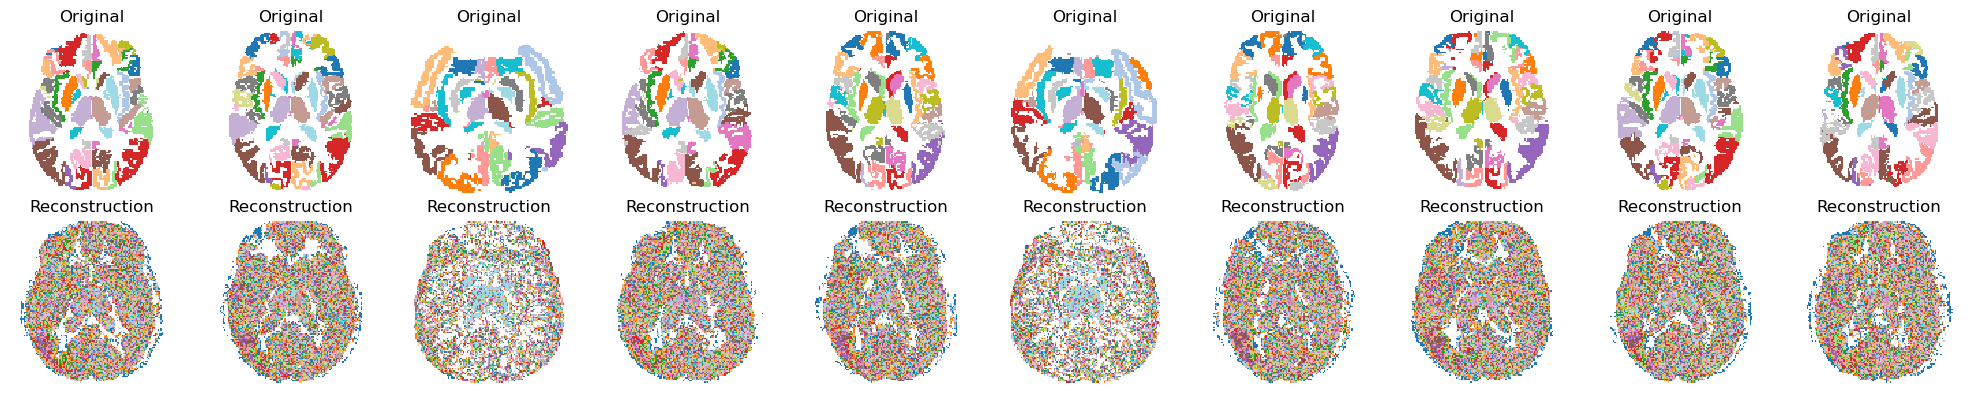

In [16]:
# 6. evaluate quality of recon (pearsons r, save a line of recons)
save_pearsons_r = "./save_pearsons_r.csv"

if not os.path.exists(save_pearsons_r):
    with open(save_pearsons_r, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["data_type", "elastic_transf_type", "num_aug", "num_comp", "gm_r", "wm_r", "csf_r"])

def get_matter_ratio(img_arr):
    gm_count = np.sum(img_arr == 1)
    wm_count = np.sum(img_arr == 2)
    csf_count = np.sum(img_arr == 3)
    total = gm_count + wm_count + csf_count

    gm_ratio = gm_count/total
    wm_ratio = wm_count/total
    csf_ratio = csf_count/total

    return gm_ratio, wm_ratio, csf_ratio

def compute_matter_ratios(imgs):
    gm_ratios = []
    wm_ratios = []
    csf_ratios = []

    for img in imgs:
        gm_ratio, wm_ratio, csf_ratio = get_matter_ratio(img)

        gm_ratios.append(gm_ratio)
        wm_ratios.append(wm_ratio)
        csf_ratios.append(csf_ratio)

    return gm_ratios, wm_ratios, csf_ratios

######

# pearsons r comparing img and recon matter ratios
imgs_gm_matter_ratio, imgs_wm_matter_ratio, imgs_csf_matter_ratio = compute_matter_ratios(test_imgs)
recon_gm_matter_ratio, recon_wm_matter_ratio, recon_csf_matter_ratio = compute_matter_ratios(imgs_test_recon)

gm_r, _ = scipy.stats.pearsonr(imgs_gm_matter_ratio, recon_gm_matter_ratio)
wm_r, _ = scipy.stats.pearsonr(imgs_wm_matter_ratio, recon_wm_matter_ratio)
csf_r, _ = scipy.stats.pearsonr(imgs_csf_matter_ratio, recon_csf_matter_ratio)

# with open(save_pearsons_r, mode='a', newline='') as f:
#     writer = csv.writer(f)
#     writer.writerow([data_type, elastic_transf_type, num_aug, num_comp, gm_r, wm_r, csf_r])

print("gm:", round(gm_r,4), "wm:", round(wm_r, 4), "csf:", round(csf_r, 4))
# save 10 imgs and their reconstruction as a png
num_save_imgs = 10
slice_idx = 70

fig, axes = plt.subplots(2, 10, figsize=(20, 4))  # 2 rows (orig, recon), 10 columns (samples)

for i in range(num_save_imgs):
    axes[0, i].imshow(np.ma.masked_where(test_imgs[i][slice_idx] == 0, test_imgs[i][slice_idx]), cmap=cmap, alpha=1.0, interpolation='nearest')
    #axes[1, i].imshow(test_imgs[i][slice_idx], cmap="gray", vmin=0, vmax=3)
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(np.ma.masked_where(imgs_test_recon[i][slice_idx] == 0, imgs_test_recon[i][slice_idx]), cmap=cmap, alpha=1.0, interpolation='nearest')
    #axes[1, i].imshow(imgs_test_recon[i][slice_idx], cmap="gray", vmin=0, vmax=3)
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show
# plt.savefig("./save_imgs/recons_" + data_type + "_" + elastic_transf_type + "_" + str(num_aug) + "_" + str(num_comp) + ".png", dpi=300)
# plt.close()


In [22]:
for num_aug in [2, 4, 6, 8]:


    for i in range(2): 
        print(i)
        
    break

0
1


In [7]:
import SimpleITK as sitk
import numpy as np

img = sitk.GetArrayFromImage(sitk.ReadImage("../../../../sub-1054168_n4.nii"))

print(np.unique(img))

[  0.   1.   2.   3.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  20.  21.  22.  23.  24.  26.  28.  30.  31.  32.
  33.  34.  35.  36.  38.  42.  43.  44.  45.  46.  47.  49.  50.  51.
  52.  53.  54.  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.
  67.  68.  69.  71.  72.  73.  74.  75.  77.  79.  81.  82.  83.  84.
  85.  86.  87.  89.  93.  94.  95.  96.  97.  98. 100. 101. 102. 251.
 252. 253. 254. 255. 256. 257. 258. 259. 260. 261. 262. 263. 264. 265.
 266. 267. 268. 269. 270.]
